<a href="https://colab.research.google.com/github/jenniferamarof2005-arch/PS_UCLV/blob/main/hola_mundo_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cargando dataset MNIST...

=== INFORMACIÓN DEL DATASET ===
Número de muestras: 1797
Número de características: 64
Número de clases: 10
Forma de las imágenes: (8, 8)

Visualizando algunos dígitos...


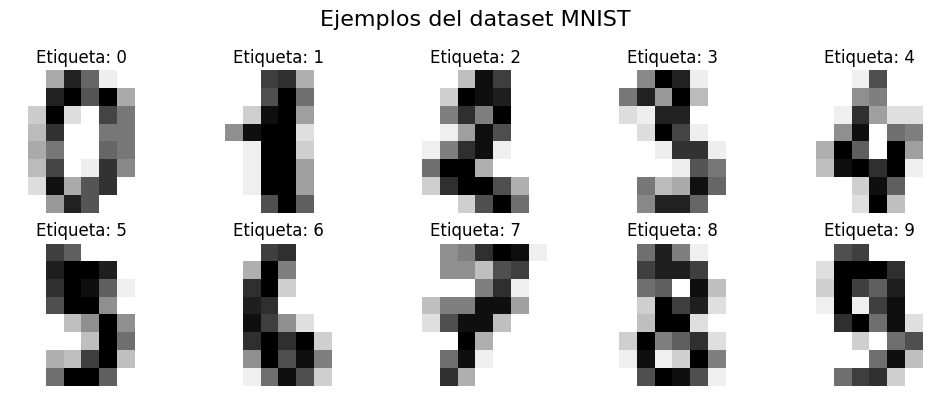


=== DIVISIÓN DE DATOS ===
Conjunto de entrenamiento: 1437 muestras
Conjunto de prueba: 360 muestras

Entrenando el modelo...

=== EVALUACIÓN DEL MODELO ===
Precisión del modelo: 0.9722 (97.22%)

Matriz de confusión:


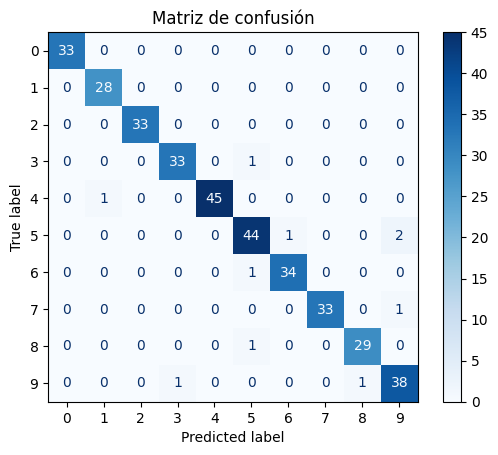


=== PREDICCIONES INDIVIDUALES ===
Imagen 1: Real=6, Predicción=6 ✓
Imagen 2: Real=1, Predicción=1 ✓
Imagen 3: Real=4, Predicción=4 ✓
Imagen 4: Real=4, Predicción=4 ✓
Imagen 5: Real=6, Predicción=6 ✓


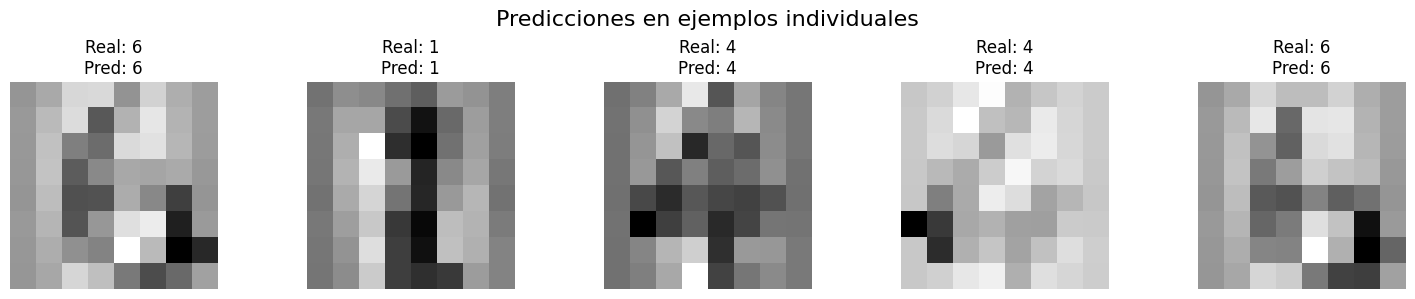


=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.93      0.95      0.94        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360


=== INFORMACIÓN ADICIONAL ===
Número de coeficientes: 10
Intercept: [-0.28981101 -0.48707208 -0.28231991  0.06297225 -0.43964256  0.01033432
 -0.40007802 -0.10413907  2.08630583 -0.15654974]

Modelo guardad

In [1]:
# -*- coding: utf-8 -*-
"""
Hola Mundo del Machine Learning - Google Colab
Clasificación de dígitos escritos a mano con MNIST
"""

# 1. Instalación de librerías (normalmente ya están instaladas en Colab)
# No es necesario ejecutar esto a menos que tengas errores
# !pip install numpy matplotlib scikit-learn

# 2. Importar las bibliotecas necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 3. Cargar el dataset MNIST (dígitos escritos a mano)
print("Cargando dataset MNIST...")
digits = datasets.load_digits()

# 4. Mostrar información básica del dataset
print("\n=== INFORMACIÓN DEL DATASET ===")
print(f"Número de muestras: {len(digits.images)}")
print(f"Número de características: {digits.data.shape[1]}")
print(f"Número de clases: {len(np.unique(digits.target))}")
print(f"Forma de las imágenes: {digits.images[0].shape}")

# 5. Visualizar algunos ejemplos del dataset
print("\nVisualizando algunos dígitos...")
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary')
    ax.set_title(f"Etiqueta: {digits.target[i]}")
    ax.axis('off')
plt.suptitle("Ejemplos del dataset MNIST", fontsize=16)
plt.tight_layout()
plt.show()

# 6. Preparar los datos
X = digits.data
y = digits.target

# Normalizar los datos (escala de 0-1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\n=== DIVISIÓN DE DATOS ===")
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

# 7. Crear y entrenar el modelo
print("\nEntrenando el modelo...")
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 8. Evaluar el modelo
print("\n=== EVALUACIÓN DEL MODELO ===")
# Predicciones
y_pred = model.predict(X_test)

# Calcular precisión
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Mostrar matriz de confusión
print("\nMatriz de confusión:")
disp = metrics.ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test, cmap=plt.cm.Blues
)
plt.title("Matriz de confusión")
plt.show()

# 9. Probar con algunos ejemplos específicos
print("\n=== PREDICCIONES INDIVIDUALES ===")
sample_indices = [0, 10, 20, 30, 40]  # Algunos índices para probar

fig, axes = plt.subplots(1, len(sample_indices), figsize=(15, 3))
for i, idx in enumerate(sample_indices):
    # Obtener una muestra del conjunto de prueba
    sample_image = X_test[idx].reshape(8, 8)
    sample_label = y_test[idx]

    # Predecir
    sample_pred = model.predict([X_test[idx]])[0]

    # Mostrar imagen
    axes[i].imshow(sample_image, cmap='binary')
    axes[i].set_title(f"Real: {sample_label}\nPred: {sample_pred}")
    axes[i].axis('off')

    # Imprimir en consola
    print(f"Imagen {i+1}: Real={sample_label}, Predicción={sample_pred} {'✓' if sample_label == sample_pred else '✗'}")

plt.suptitle("Predicciones en ejemplos individuales", fontsize=16)
plt.tight_layout()
plt.show()

# 10. Reporte de clasificación detallado
print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(metrics.classification_report(y_test, y_pred))

# 11. Información adicional sobre el modelo
print("\n=== INFORMACIÓN ADICIONAL ===")
print(f"Número de coeficientes: {len(model.coef_)}")
print(f"Intercept: {model.intercept_}")

# 12. Guardar el modelo (opcional)
import joblib
joblib.dump(model, 'modelo_mnist.pkl')
print("\nModelo guardado como 'modelo_mnist.pkl'")
print("¡Hola Mundo del Machine Learning completado!")